# ResNet50 Training Pipeline

Fine-tunes a pretrained ResNet50 backbone for 3-class chest X-ray classification: `NORMAL`, `BACTERIAL_PNEUMONIA`, and `VIRAL_PNEUMONIA`.

## Training strategy

| Phase | Epochs | Layers trained | Learning rate |
|---|---|---|---|
| 1 — Head warm-up | 1–3 | Head only (`Dropout → Linear`) | `1e-4` |
| 2 — Fine-tuning | 4+ | Head + `layer3` + `layer4` | `5e-6` |

Freezing the backbone for the first 3 epochs prevents the randomly-initialised head from corrupting pretrained features before it has stable gradients. Unfreezing only the two deepest residual stages (`layer3`, `layer4`) in Phase 2 fine-tunes the high-level semantic features while keeping low-level edge detectors (`layer1`, `layer2`) fixed.

## Key design decisions
- **Class-weighted loss**: weights inversely proportional to class frequency to handle the imbalance between BACTERIAL (largest) and VIRAL (smallest) classes
- **Label smoothing (0.1)**: softens targets to prevent overconfidence, which helps on the hard VIRAL class
- **Early stopping (patience=4)**: halts training when validation loss stops improving for 4 consecutive epochs
- **GradScaler**: enables mixed-precision training; no-ops gracefully on CPU

## Outputs
- `resnet50_pneumonia.pth` — best model weights (lowest validation loss)
- `classes.json` — class index-to-label mapping used by the Streamlit inference app

In [1]:
# Install this once
!pip install import-ipynb
!pip install import-ipynb scikit-learn

## DataLoader Import

Imports the cleaned datasets and preprocessing transforms from `Preprocessing_Pipeline.ipynb`. This gives us:
- `prep.train_dataset` / `prep.val_dataset` / `prep.test_dataset` — `ImageFolder` datasets after autoencoder-based outlier removal
- `prep.train_dataset.classes` — ordered class name list used to configure the model output layer

The full preprocessing pipeline (CLAHE, noise reduction, normalisation, augmentations) is already embedded in each dataset object. No additional transforms are applied here.

Cleaning datasets using autoencoder...

Processing class 0...


Class 0 Epoch 1, Total Loss: 31.9097


Class 0 Epoch 2, Total Loss: 19.4247


Class 0 Epoch 3, Total Loss: 17.7753


Class 0: removed 127 samples

Processing class 1...


...

Class 1: removed 8 samples

Processing class 2...


Class 2 Epoch 1, Total Loss: 4.0731


Class 2 Epoch 2, Total Loss: 4.0727


Class 2: removed 5 samples

Balancing train dataset...
Before balancing: {np.int64(0): np.int64(2403), np.int64(1): np.int64(1273), np.int64(2): np.int64(1277)}
After balancing: {np.int64(0): np.int64(1273), np.int64(1): np.int64(1273), np.int64(2): np.int64(1273)}
Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Train size: 3819
Validation size: 186
Test size: 604


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0735948].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0137256].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0735948].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0855688].


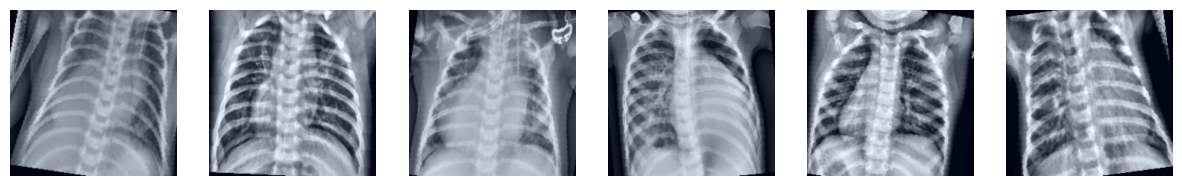

🔹 Train Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 1273 (33.33%)
NORMAL: 1273 (33.33%)
VIRAL_PNEUMONIA: 1273 (33.33%)

🔹 Test Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 234 (38.74%)
NORMAL: 227 (37.58%)
VIRAL_PNEUMONIA: 143 (23.68%)
🔹 Validation Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 62 (33.33%)
NORMAL: 62 (33.33%)
VIRAL_PNEUMONIA: 62 (33.33%)


In [2]:
import import_ipynb
import Preprocessing_Pipeline as prep

In [3]:
from torch.utils.data import DataLoader

train_loader = DataLoader(prep.train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(prep.val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(prep.test_dataset, batch_size=32, shuffle=False)

In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


## ResNet50 Architecture

ResNet50 is a 50-layer residual network (~25M parameters). Its core innovation is **skip connections**: each residual block adds its input directly to its output, allowing gradients to flow backwards without vanishing. This makes it possible to train deep networks effectively on relatively small datasets.

The standard ImageNet classification head (`fc: Linear(2048 → 1000)`) is replaced with:
```
Dropout(p=0.5) → Linear(2048 → num_classes)
```
Dropout before the final layer provides regularisation at the boundary between the pretrained backbone and the new task-specific head.

In [5]:
import torch.nn as nn
from torchvision import models

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_classes = len(prep.train_dataset.classes)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, num_classes)
)
model = model.to(device)

In [6]:
from collections import Counter

counts = Counter(prep.train_dataset.targets)
total = sum(counts.values())
class_weights = [total / counts[i] for i in range(len(counts))]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

### Class Weighting

Computes inverse-frequency weights for each class: `weight[i] = total_samples / count[i]`. This means errors on the small `VIRAL_PNEUMONIA` class are penalised proportionally more than errors on the larger `BACTERIAL_PNEUMONIA` class. The weights are passed directly to `CrossEntropyLoss`, making the loss surface reflect clinical priority rather than dataset frequency.

## Training Configuration

| Parameter | Value | Rationale |
|---|---|---|
| Loss function | `CrossEntropyLoss` (weighted) | Class weights inversely proportional to sample count; penalises minority-class errors more heavily |
| Label smoothing | `0.1` | Softens one-hot targets to prevent overconfidence; helps on the hard VIRAL class |
| Optimizer | `Adam` | Adaptive per-parameter learning rates; robust without extensive LR tuning |
| Head LR (Phase 1) | `1e-4` | Fast convergence for the randomly-initialised head |
| Fine-tune LR (Phase 2) | `5e-6` | Low enough to nudge pretrained weights without overwriting them |
| Weight decay | `1e-4` | L2 regularisation |
| LR scheduler | `ReduceLROnPlateau` | Multiplies LR by 0.3 after 2 epochs without val loss improvement |
| Max epochs | `20` | Upper bound; early stopping typically triggers earlier |
| Freeze epochs | `3` | Epochs before backbone unfreezing |
| Early stop patience | `4` | Epochs to wait before halting training |
| Gradient clipping | `2.0` | Caps global gradient norm to prevent destructive updates from bad batches |

In [7]:
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import copy

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer = optim.Adam(
    model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.3
)

EPOCHS = 20
PATIENCE = 4

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_loss = float('inf')
epochs_no_improve = 0
best_model_weights = copy.deepcopy(model.state_dict())

use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

C:\Users\noora\AppData\Local\Temp\ipykernel_12220\975439226.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


## Training Loop

`train_one_epoch` runs one full pass over the training set. Key implementation details:

- **Mixed precision** (`torch.cuda.amp.autocast`): forward pass computes in float16 where safe, reducing GPU memory and increasing throughput. `GradScaler` rescales gradients back to float32 before the optimizer step to prevent underflow
- **Gradient clipping** (`clip_grad_norm_=2.0`): caps the global L2 norm of all gradients, preventing a single bad batch from causing a destructive parameter update
- Returns average batch loss and per-epoch accuracy for tracking

In [8]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    loop = tqdm(loader, desc="Training", leave=False)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader), correct / total

## Evaluation Loop

`evaluate` runs a full pass over a dataloader under `torch.no_grad()`, which disables gradient computation and approximately halves memory usage. This function is used identically for both validation (after each training epoch) and final test evaluation, ensuring both are computed the same way.

In [9]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

## Main Training Loop

Runs the full training cycle with two-phase fine-tuning, live loss plotting, and early stopping:

1. **Epochs 1–`FREEZE_EPOCHS`**: only the classification head is trained; backbone is frozen
2. **At epoch `FREEZE_EPOCHS`**: upper backbone layers are unfrozen and the optimizer is rebuilt at a lower learning rate to fine-tune pretrained weights gently
3. **Each epoch**: train → validate → step the LR scheduler → check early stopping → update live loss plot
4. **Best model checkpointing**: the state dict is saved in memory whenever validation loss reaches a new minimum. If early stopping triggers, training ends with the best weights already captured and ready to restore


Epoch 1/20


Training:   0%|          | 0/120 [00:00<?, ?it/s]C:\Users\noora\AppData\Local\Temp\ipykernel_12220\2295438348.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
                                                                      

Train Loss: 1.0991 | Train Acc: 0.3459
Val   Loss: 1.0786 | Val   Acc: 0.4731
✅ Best model updated


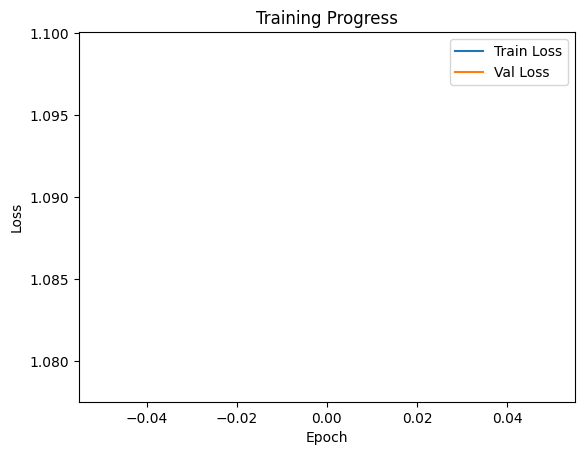


Epoch 2/20


Train Loss: 1.0822 | Train Acc: 0.4053
Val   Loss: 1.0580 | Val   Acc: 0.5538
✅ Best model updated


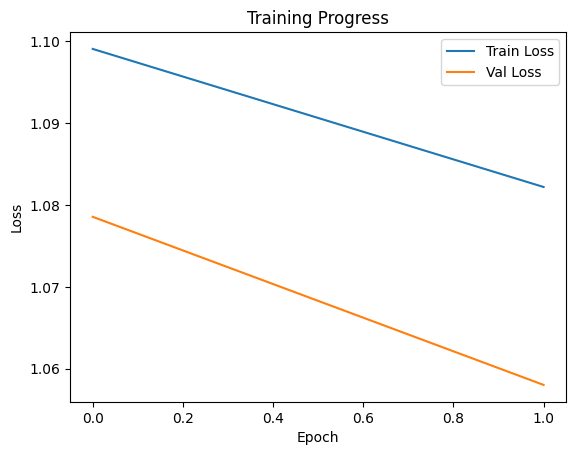


Epoch 3/20


Train Loss: 1.0589 | Train Acc: 0.4818
Val   Loss: 1.0479 | Val   Acc: 0.6452
✅ Best model updated


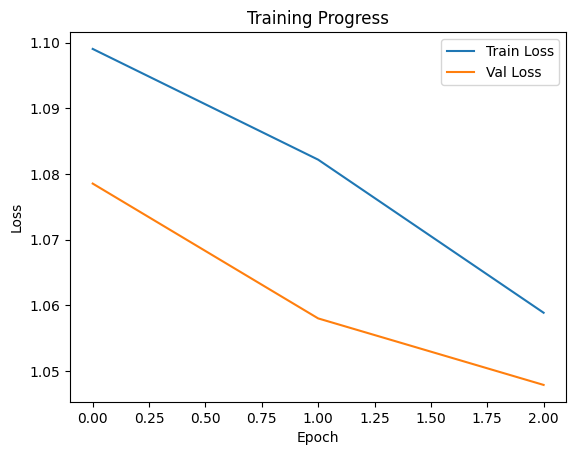


Epoch 4/20


Train Loss: 1.0370 | Train Acc: 0.4925
Val   Loss: 1.0089 | Val   Acc: 0.6989
✅ Best model updated


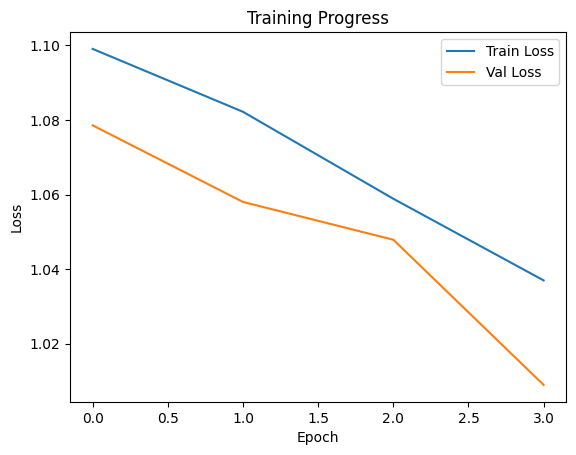


Epoch 5/20


Train Loss: 0.9987 | Train Acc: 0.5674
Val   Loss: 0.9820 | Val   Acc: 0.7419
✅ Best model updated


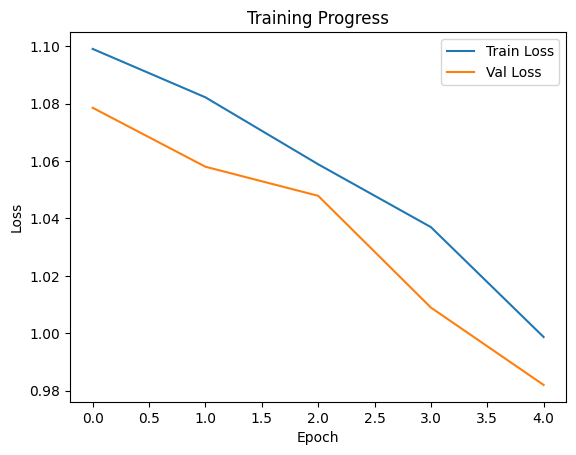


Epoch 6/20


Train Loss: 0.9718 | Train Acc: 0.6122
Val   Loss: 0.9574 | Val   Acc: 0.6882
✅ Best model updated


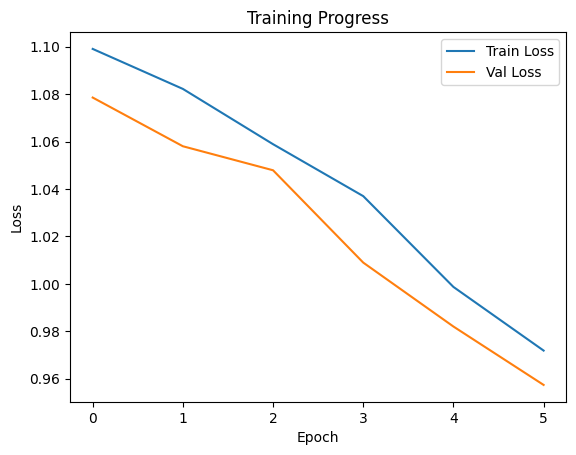


Epoch 7/20


Train Loss: 0.9496 | Train Acc: 0.6481
Val   Loss: 0.9414 | Val   Acc: 0.6505
✅ Best model updated


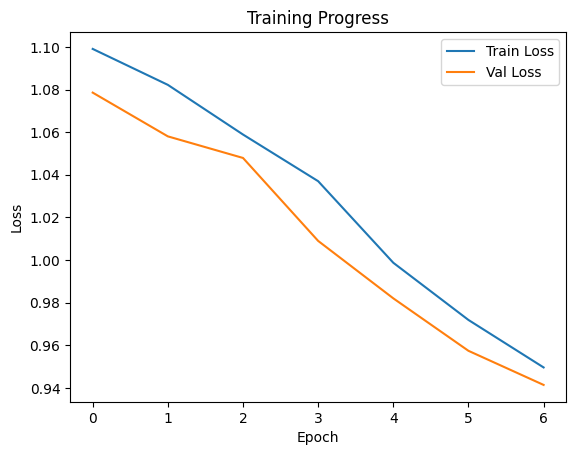


Epoch 8/20


Train Loss: 0.9305 | Train Acc: 0.6426
Val   Loss: 0.9300 | Val   Acc: 0.6398
✅ Best model updated


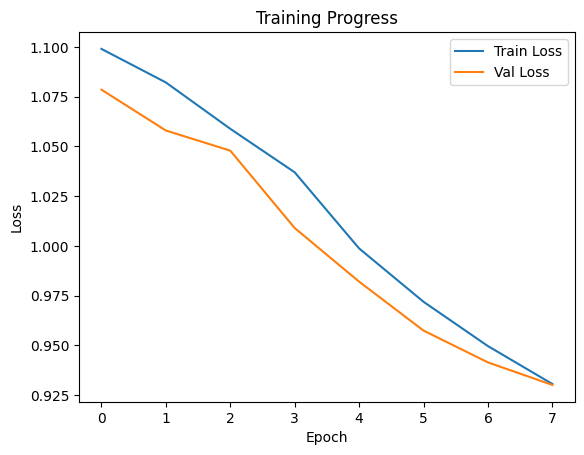


Epoch 9/20


Train Loss: 0.9192 | Train Acc: 0.6559
Val   Loss: 0.9167 | Val   Acc: 0.6290
✅ Best model updated


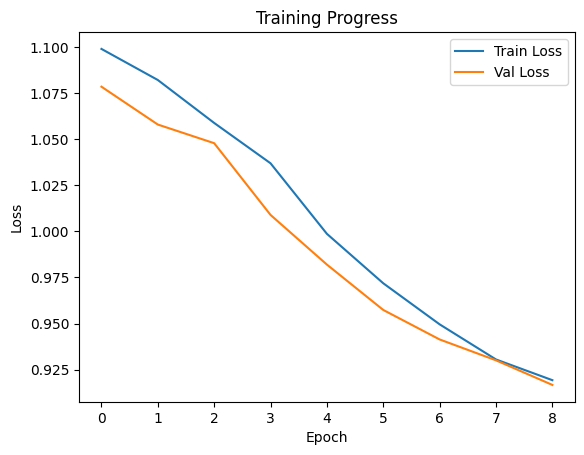


Epoch 10/20


Train Loss: 0.8971 | Train Acc: 0.6876
Val   Loss: 0.8945 | Val   Acc: 0.6075
✅ Best model updated


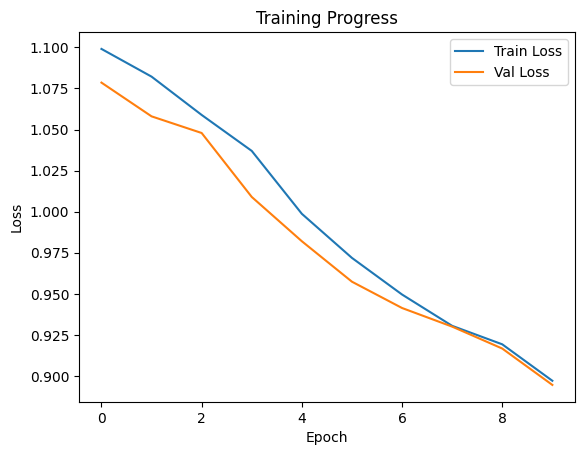


Epoch 11/20


Train Loss: 0.8761 | Train Acc: 0.6866
Val   Loss: 0.8604 | Val   Acc: 0.6183
✅ Best model updated


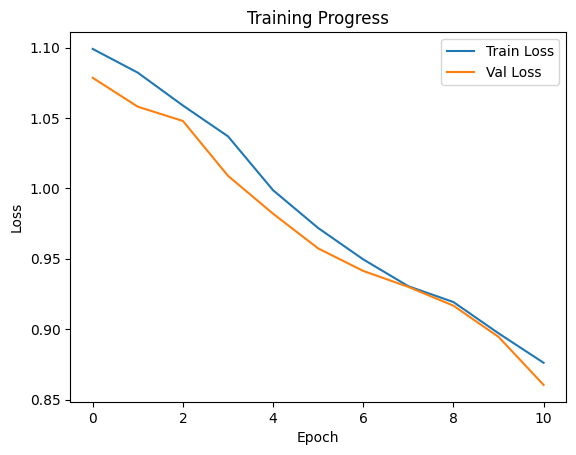


Epoch 12/20


Train Loss: 0.8600 | Train Acc: 0.7020
Val   Loss: 0.8592 | Val   Acc: 0.6129
✅ Best model updated


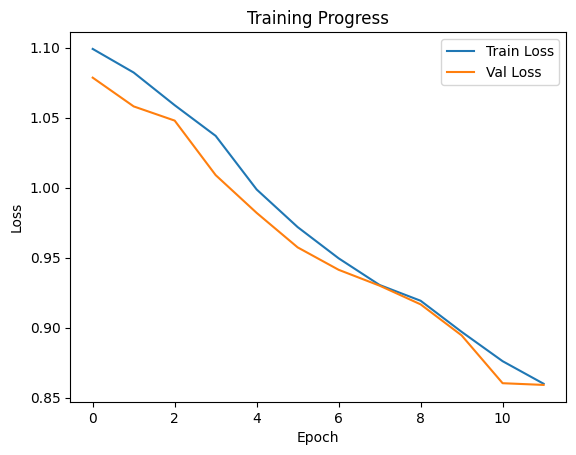


Epoch 13/20


Train Loss: 0.8457 | Train Acc: 0.6892
Val   Loss: 0.8171 | Val   Acc: 0.6290
✅ Best model updated


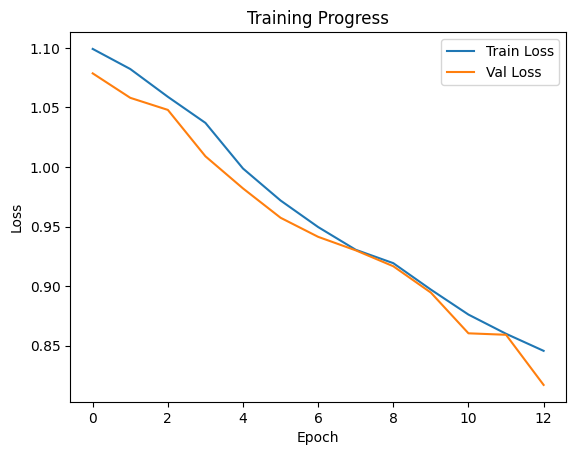


Epoch 14/20


Train Loss: 0.8170 | Train Acc: 0.6949
Val   Loss: 0.7414 | Val   Acc: 0.6559
✅ Best model updated


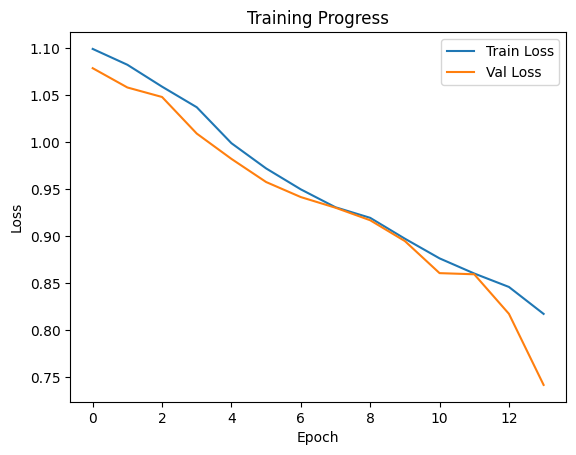


Epoch 15/20


Train Loss: 0.7652 | Train Acc: 0.7196
Val   Loss: 0.7643 | Val   Acc: 0.7097
⚠️ No improvement for 1 epochs


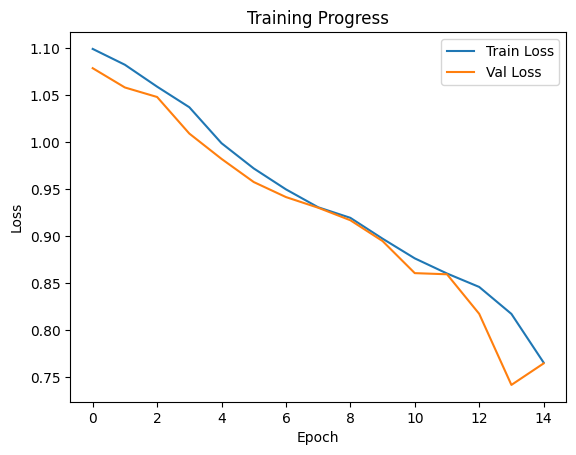


Epoch 16/20


Train Loss: 0.7358 | Train Acc: 0.7350
Val   Loss: 0.6867 | Val   Acc: 0.7473
✅ Best model updated


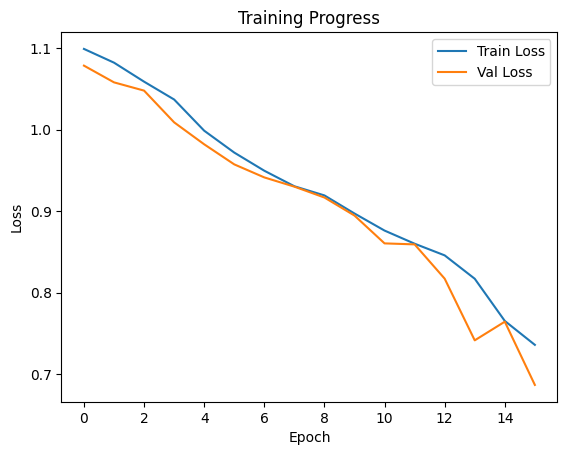


Epoch 17/20


Train Loss: 0.7142 | Train Acc: 0.7337
Val   Loss: 0.6131 | Val   Acc: 0.7957
✅ Best model updated


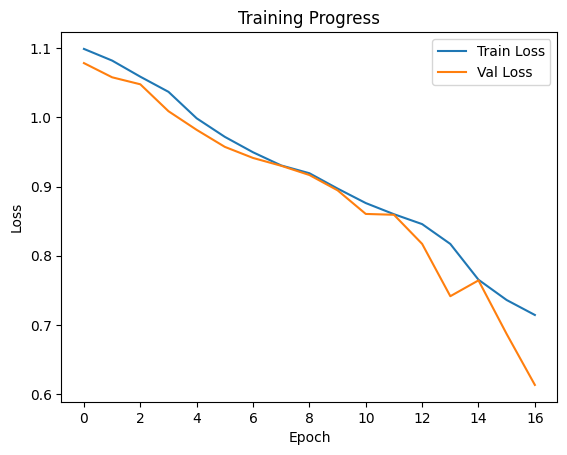


Epoch 18/20


Train Loss: 0.6751 | Train Acc: 0.7484
Val   Loss: 0.6377 | Val   Acc: 0.7903
⚠️ No improvement for 1 epochs


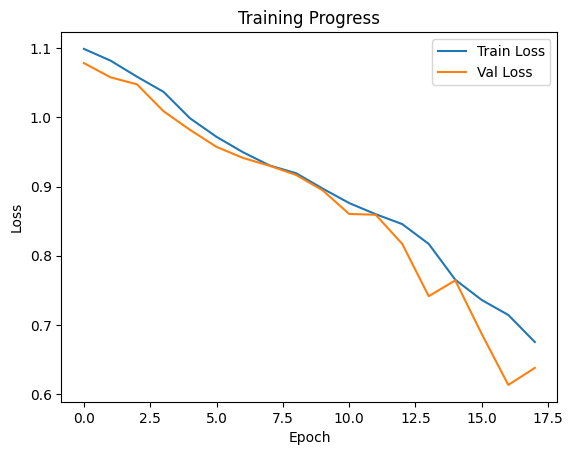


Epoch 19/20


Train Loss: 0.6539 | Train Acc: 0.7625
Val   Loss: 0.6320 | Val   Acc: 0.7742
⚠️ No improvement for 2 epochs


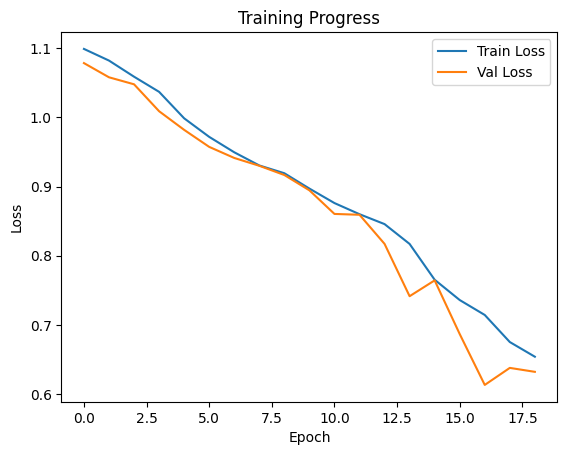


Epoch 20/20


Train Loss: 0.6538 | Train Acc: 0.7625
Val   Loss: 0.5349 | Val   Acc: 0.8387
✅ Best model updated


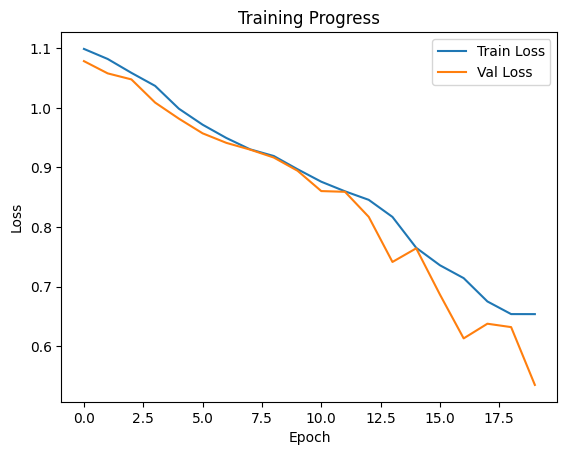

In [10]:
plt.ion()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # 🔥 EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        print("✅ Best model updated")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement for {epochs_no_improve} epochs")

    if epochs_no_improve >= PATIENCE:
        print("🛑 Early stopping triggered")
        break

    # 📊 LIVE GRAPH
    plt.clf()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Progress")
    plt.pause(0.1)

plt.ioff()
plt.show()

## Restore Best Weights and Evaluate

Restores the model state dict that achieved the lowest validation loss during training, then runs a single final evaluation on the held-out test set. The test set is touched only here — it was never used for training decisions or scheduler stepping.

In [11]:
model.load_state_dict(best_model_weights)

<All keys matched successfully>

In [12]:
test_loss, test_acc = evaluate(model, test_loader, criterion)

print("\nTest Results:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")


Test Results:
Loss: 0.6346
Accuracy: 0.8129


### F1 Score

Weighted F1 accounts for class imbalance by averaging per-class F1 scores weighted by support (number of true instances per class). This is a more honest summary metric than accuracy for an imbalanced 3-class problem.

In [13]:
from sklearn.metrics import f1_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 🔥 F1 Score
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8153


In [14]:
torch.save(model.state_dict(), "resnet50_pneumonia.pth")

import json
with open("classes.json", "w") as f:
    json.dump(prep.train_dataset.classes, f)

### Classification Report

Per-class breakdown of precision, recall, and F1-score on the test set. This is more informative than overall accuracy for an imbalanced dataset — a model that always predicts `NORMAL` or `BACTERIAL_PNEUMONIA` could still score high accuracy while completely missing `VIRAL_PNEUMONIA`. The per-class recall column is especially important in a medical screening context where false negatives carry clinical risk.

In [15]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=prep.train_dataset.classes))

                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.87      0.78      0.82       234
             NORMAL       0.87      0.85      0.86       227
    VIRAL_PNEUMONIA       0.67      0.80      0.73       143

           accuracy                           0.81       604
          macro avg       0.80      0.81      0.80       604
       weighted avg       0.82      0.81      0.82       604

